# Prediccion de Radiacion Solar con BiLSTM
## Demo de producto — Valle de Aburra, Medellin
### Climate Week 2026 · Emergente

---


| Paso | Descripcion |
|------|-------------|
| 1 | Los datos de pronostico GFS que entran al modelo (ventana de 37 horas) |
| 2 | Como la BiLSTM procesa la secuencia completa  |
| 3 | La prediccion para el 15 de septiembre de 2021 |
| 4 | Comparacion con las mediciones reales de SIATA |

**Fecha objetivo del demo:** 15 de septiembre de 2021  
**Ubicacion:** Valle de Aburra, Medellin (6.25°N, 75.5°W, 1485 m s.n.m.)

In [1]:
# ── Install required packages (run once in Colab) ─────────────────
import subprocess, sys

_PACKAGES = ['xarray', 'h5netcdf', 'pvlib', 'torch',
             'pandas', 'numpy', 'matplotlib', 'seaborn']
for _pkg in _PACKAGES:
    try:
        __import__(_pkg)
    except ImportError:
        print(f'Installing {_pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', _pkg])

# ── Standard imports ──────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import torch
import xarray as xr
warnings.filterwarnings('ignore')

# ── Project root detection ────────────────────────────────────────
# Walk up from cwd until we find the _4_LSTM_modules marker folder
_search = os.path.abspath(os.getcwd())
PROJECT_ROOT = None
for _ in range(6):
    if os.path.isdir(os.path.join(_search, '_4_LSTM_modules')):
        PROJECT_ROOT = _search
        break
    _search = os.path.dirname(_search)

if PROJECT_ROOT is None:
    # Manual override — set this path if auto-detection fails
    PROJECT_ROOT = r'C:\Users\isabe\Projects\codigors\carpetasdetrabajo'

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f'PROJECT_ROOT -> {PROJECT_ROOT}')

# ── Matplotlib style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.color':        '#E8E8E8',
    'grid.linewidth':    0.8,
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'legend.fontsize':   10,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
})

# ── Brand colour palette ──────────────────────────────────────────
COLOR_BILSTM = '#2E86AB'   # blue        — BiLSTM prediction
COLOR_SIATA  = '#1B4332'   # dark green  — real SIATA measurement
COLOR_GFS    = '#E07A5F'   # orange      — GFS raw forecast
COLOR_CS     = '#A8DADC'   # light blue  — clear-sky reference

print('Entorno configurado correctamente')

PROJECT_ROOT -> C:\Users\isabe\Projects\codigors\carpetasdetrabajo
Entorno configurado correctamente


## Paso 1: Que datos entran al modelo?

```
<- 18h pasado ----------- hora central ----------- 18h futuro ->

 t-18  t-17  ...  t-2  t-1  [ t=0 ]  t+1  t+2  ...  t+17  t+18
                                 ^
                          HORA A PREDECIR
```

**Para cada una de las 37 horas de la ventana se incluyen 79 variables:**

| Grupo | Variables principales | Fuente |
|---|---|---|
| Radiacion GFS | `dswrf1`, `kc` (CSI), `ks` (KC) | GFS — 4 lanzamientos |
| Nubosidad GFS | `TCDC`, `LCDC`, `MCDC`, `HCDC`, `HGT` | GFS — 4 lanzamientos |
| Meteorologia GFS | `TMP`, `RH`, `CAPE`, `HPBL`, `WIND`, `PWAT`, `DLWRF` | GFS — 4 lanzamientos |
| Solar / meta | `zenith`, `step` | pvlib / GFS |
| Climatologia SIATA | `clim_mean_csi`, `clim_std_csi`, `clim_prob_*`, etc. | SIATA historico |

**Total: 79 variables x 37 pasos = 2.923 valores por prediccion**

A continuacion se muestra la ventana real que el modelo recibio para predecir las 12:00h del 15 de septiembre de 2021.

In [2]:
# ── File paths (relative to PROJECT_ROOT) ──────────────────────────
_NPZ_CANDIDATES = [
    os.path.join(PROJECT_ROOT, '_4_LSTM_modules', 'Prepared_data',
                 '4launch_multfeat_sym18_clim79_FIXED.npz'),   # spec name
    os.path.join(PROJECT_ROOT, '_4_LSTM_modules', 'Prepared_data',
                 '4launch_multfeat_sym18_clim.npz'),            # actual file
]

# ── Load NPZ ──────────────────────────────────────────────────────
try:
    NPZ_PATH = next(p for p in _NPZ_CANDIDATES if os.path.exists(p))
    data = np.load(NPZ_PATH, allow_pickle=True)
    feature_vars = list(data['feature_vars'])
    print(f'NPZ cargado : {os.path.basename(NPZ_PATH)}')
    print(f'  X_train shape : {data["X_train"].shape}')
    print(f'  Features      : {len(feature_vars)}')
except StopIteration:
    print('ERROR: No se encontro el archivo NPZ.')
    print('  Rutas buscadas:')
    for p in _NPZ_CANDIDATES:
        print(f'    {p}')
    raise

# ── Merge all splits and locate 2021-09-15 12:00 ──────────────────
TARGET_DT = pd.Timestamp('2021-09-15 12:00:00')

X_all = np.concatenate([data['X_train'], data['X_val'], data['X_test']])
y_all = np.concatenate([data['y_train'], data['y_val'], data['y_test']])
t_all = pd.to_datetime(
    np.concatenate([data['t_train'], data['t_val'], data['t_test']])
)

mask_target = (t_all == TARGET_DT)
if not mask_target.any():
    raise ValueError(
        f'No se encontro la secuencia para {TARGET_DT}. '
        'Verificar que el NPZ contiene datos de septiembre 2021.'
    )

idx       = int(np.where(mask_target)[0][0])
X_seq     = X_all[idx]    # shape (37, 79)
n_train   = len(data['X_train'])
n_val     = len(data['X_val'])
split_tag = ('train' if idx < n_train
             else 'val' if idx < n_train + n_val
             else 'test')
print(f'  Secuencia objetivo : {TARGET_DT}  [split: {split_tag}]')
print(f'  Forma de ventana   : {X_seq.shape}')

# ── Select 10 most informative features for the display table ─────
TEN_VARS = [
    'kc_0700', 'ks_0700', 'dswrf1_0700', 'TCDC_ent_0700',
    'LCDC_ent_0700', 'CAPE_surface_0700', 'RH_2m_0700',
    'TMP_surface_0700', 'HPBL_surface_0700', 'zenith',
]
avail_vars  = [v for v in TEN_VARS if v in feature_vars]
col_indices = [feature_vars.index(v) for v in avail_vars]

# Build one timestamp per window step (local Colombia time)
win_start  = TARGET_DT + pd.Timedelta(hours=-18)
timestamps = [win_start + pd.Timedelta(hours=i) for i in range(37)]
paso_label = [f't{i - 18:+d}' if i != 18 else '[t=0]' for i in range(37)]

df_window = pd.DataFrame(
    X_seq[:, col_indices],
    columns=avail_vars,
).round(3)
df_window.insert(0, 'Paso', paso_label)
df_window.index = [ts.strftime('%Y-%m-%d %H:%M') for ts in timestamps]
df_window.index.name = 'Timestamp (local)'

print(f'\nVentana de entrada al modelo: 37 pasos temporales')
print(f'Variables seleccionadas ({len(avail_vars)} de {len(feature_vars)} totales)')

# ── Style the table ───────────────────────────────────────────────
def _style_window_row(row):
    pos = df_window.index.get_loc(row.name)
    if pos < 18:
        return ['background-color: #F5F5F5; color: #555555'] * len(row)
    elif pos == 18:
        return [
            f'background-color: {COLOR_BILSTM}33; '
            'font-weight: bold; border: 2px solid #2E86AB'
        ] * len(row)
    else:
        return ['background-color: #FFFDE7'] * len(row)

styled_window = (
    df_window.style
    .apply(_style_window_row, axis=1)
    .set_caption(
        'Ventana de entrada BiLSTM — 15-sep-2021 12:00h '
        '(fila central en azul = hora a predecir | '
        'gris = pasado | amarillo = futuro)'
    )
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '12px'), ('font-weight', 'bold'), ('color', '#333')]},
        {'selector': 'th',
         'props': [('background-color', COLOR_BILSTM),
                   ('color', 'white'), ('font-size', '11px')]},
        {'selector': 'td',
         'props': [('font-size', '10.5px'), ('padding', '3px 8px')]},
    ])
)
styled_window

NPZ cargado : 4launch_multfeat_sym18_clim.npz


  X_train shape : (24889, 37, 79)
  Features      : 79


  Secuencia objetivo : 2021-09-15 12:00:00  [split: train]
  Forma de ventana   : (37, 79)

Ventana de entrada al modelo: 37 pasos temporales
Variables seleccionadas (10 de 79 totales)


,Paso,kc_0700,ks_0700,dswrf1_0700,TCDC_ent_0700,LCDC_ent_0700,CAPE_surface_0700,RH_2m_0700,TMP_surface_0700,HPBL_surface_0700,zenith
Timestamp (local),,,,,,,,,,,
2021-09-14 18:00,t-18,0.860000,0.401000,0.046000,1.000000,0.005000,0.118000,0.928000,0.228000,0.001000,0.002000
2021-09-14 19:00,t-17,0.000000,0.000000,0.000000,1.000000,0.023000,0.048000,0.949000,0.205000,0.002000,0.000000
2021-09-14 20:00,t-16,0.000000,0.000000,0.000000,1.000000,0.058000,0.017000,0.957000,0.185000,0.003000,0.000000
2021-09-14 21:00,t-15,0.000000,0.000000,0.000000,1.000000,0.072000,0.006000,0.963000,0.172000,0.004000,0.000000
2021-09-14 22:00,t-14,0.000000,0.000000,0.000000,1.000000,0.106000,0.008000,0.969000,0.160000,0.006000,0.000000
2021-09-14 23:00,t-13,0.000000,0.000000,0.000000,1.000000,0.125000,0.005000,0.972000,0.155000,0.004000,0.000000
2021-09-15 00:00,t-12,0.000000,0.000000,0.000000,1.000000,0.199000,0.002000,0.978000,0.143000,0.003000,0.000000
2021-09-15 01:00,t-11,0.000000,0.000000,0.000000,1.000000,0.195000,0.001000,0.981000,0.125000,0.002000,0.000000
2021-09-15 02:00,t-10,0.000000,0.000000,0.000000,1.000000,0.158000,0.001000,0.976000,0.135000,0.003000,0.000000


## Paso 2: El modelo procesa la secuencia completa

**Arquitectura del modelo:**

```
Entrada (37 x 79)
      |
      v
  LayerNorm
      |
   +--+--+
   |     |
   v     v
LSTM->  <-LSTM
(fwd)   (bwd)
   |     |
   +--+--+
      |   (x 3 capas, hidden=96)
      v
 Atencion Bahdanau
 (aprende que horas importan mas)
      |
      v
  Dropout (0.25)
      |
      v
  Capa lineal  -->  Sigmoid  -->  CSI predicho [0,1]
```

**Descalado fisico:**  
`GHI predicho (W/m2) = CSI predicho x GHI cielo despejado (Ineichen)`


In [3]:
# ── Paths ──────────────────────────────────────────────────────────
MODEL_PATH = os.path.join(
    PROJECT_ROOT,
    '_4_LSTM_modules', '_runs', '4launch_multfeat_sym',
    '4launch_Multfeat_sym18_clim79_FIXED_BiLSTM_attn_20260706_102943',
    'best_model.pt',
)
CS_GHI_PATH = os.path.join(
    PROJECT_ROOT,
    '_3_Data_preparation_for_LSTM', 'Preparation_data',
    '_01_CSI_EXT_radiation', 'Ineichen_GHI',
    'CSI_GHI_grid25_avg_with_horizon_and_enhancement_with_bias_correct2.nc',
)

# ── Load model ────────────────────────────────────────────────────
try:
    from _4_LSTM_modules.NN_modules.BiLSTMRegressor import BiLSTMRegressor

    model = BiLSTMRegressor(
        n_feat=79, hidden=96, num_layers=3, dropout=0.25, activation='sigmoid'
    )
    state = torch.load(MODEL_PATH, map_location='cpu', weights_only=True)
    model.load_state_dict(state)
    model.eval()
    n_params = sum(p.numel() for p in model.parameters())
    print(f'Modelo cargado : {n_params:,} parametros')
    print(f'  Archivo       : {os.path.basename(MODEL_PATH)}')
except FileNotFoundError:
    print('ERROR: No se encontro el archivo del modelo:')
    print(f'  {MODEL_PATH}')
    raise
except Exception as e:
    print(f'ERROR al cargar el modelo: {e}')
    raise

# ── Find all sequences for 2021-09-15 (daytime 06-18h) ───────────
mask_day = (
    (t_all >= '2021-09-15 06:00:00') &
    (t_all <= '2021-09-15 18:00:00')
)
order   = np.argsort(t_all[mask_day])
X_day   = X_all[mask_day][order]
y_day   = y_all[mask_day][order]
t_day   = t_all[mask_day][order]
print(f'\nSecuencias encontradas para 2021-09-15: {len(t_day)} de 13 horas diurnas')

# ── Run inference ─────────────────────────────────────────────────
with torch.no_grad():
    X_tensor  = torch.tensor(X_day, dtype=torch.float32)
    csi_pred  = model(X_tensor).numpy()   # shape (13,) — normalised CSI in (0,1)

print(f'Rango CSI predicho : [{csi_pred.min():.3f}, {csi_pred.max():.3f}]')

# ── Physical descaling: GHI = CSI_pred x clear_sky_ghi ───────────
try:
    ds_cs      = xr.open_dataset(CS_GHI_PATH, engine='h5netcdf')
    t_cs_all   = pd.to_datetime(ds_cs['observation_time'].values)
    v_cs_all   = ds_cs['clear_sky_ghi'].values.squeeze()   # (N,) after squeezing spatial dims
    ds_cs.close()

    # Align clear-sky values to the inference timestamps
    cs_series  = pd.Series(v_cs_all, index=t_cs_all)
    cs_values  = cs_series.reindex(t_day).values
    print(f'Clear-sky GHI cargado: rango [{cs_values.min():.0f}, {cs_values.max():.0f}] W/m2')
except FileNotFoundError:
    print('ERROR: No se encontro el archivo de cielo despejado:')
    print(f'  {CS_GHI_PATH}')
    raise

ghi_pred = csi_pred  * cs_values   # W/m2
ghi_true = y_day     * cs_values   # W/m2 (ground truth, used later)

# ── Build results DataFrame ───────────────────────────────────────
df_pred = pd.DataFrame({
    'hora':          [ts.strftime('%H:%M') for ts in t_day],
    'csi_pred':      np.round(csi_pred,  3),
    'ghi_pred':      np.round(ghi_pred,  1),
    'clear_sky_ghi': np.round(cs_values, 1),
    'csi_true':      np.round(y_day,     3),
    'ghi_true':      np.round(ghi_true,  1),
}, index=t_day)
df_pred.index.name = 'timestamp_local'

print(f'\nPredicciones generadas para 2021-09-15')
print(f'Horas con datos: {len(df_pred)} de 13 horas diurnas')

Modelo cargado : 581,920 parametros
  Archivo       : best_model.pt

Secuencias encontradas para 2021-09-15: 13 de 13 horas diurnas
Rango CSI predicho : [0.300, 0.929]


Clear-sky GHI cargado: rango [1, 1068] W/m2

Predicciones generadas para 2021-09-15
Horas con datos: 13 de 13 horas diurnas


In [4]:
# ── Styled prediction table ────────────────────────────────────────
from matplotlib.colors import LinearSegmentedColormap

display_df = df_pred[['hora', 'csi_pred', 'ghi_pred', 'clear_sky_ghi']].copy()
display_df.columns = ['Hora', 'CSI predicho', 'GHI predicho (W/m2)', 'Clear-sky (W/m2)']
display_df = display_df.reset_index(drop=True)

# GHI colour gradient: white -> orange
_cm_orange = LinearSegmentedColormap.from_list('wh_orange', ['#FFFFFF', '#E07A5F'], N=256)
_peak_cs   = float(df_pred['clear_sky_ghi'].max()) * 1.05

styled_pred = (
    display_df.style
    .background_gradient(
        cmap=_cm_orange,
        subset=['GHI predicho (W/m2)'],
        vmin=0,
        vmax=_peak_cs,
    )
    .format({'CSI predicho': '{:.3f}',
             'GHI predicho (W/m2)': '{:.0f}',
             'Clear-sky (W/m2)': '{:.0f}'})
    .set_caption('Predicciones BiLSTM — 15 de septiembre 2021')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '13px'), ('font-weight', 'bold'), ('color', '#333')]},
        {'selector': 'th',
         'props': [('background-color', COLOR_BILSTM), ('color', 'white')]},
        {'selector': 'td',
         'props': [('padding', '4px 12px'), ('font-size', '11px')]},
    ])
)

# ── Summary statistics ────────────────────────────────────────────
_mask_pos   = ghi_pred > 0
_avg_ghi    = ghi_pred[_mask_pos].mean()
_peak_idx   = int(np.argmax(ghi_pred))
_peak_hour  = df_pred['hora'].iloc[_peak_idx]
_peak_ghi   = ghi_pred[_peak_idx]

print(f'GHI promedio del dia               : {_avg_ghi:.0f} W/m2')
print(f'Hora de maxima radiacion predicha  : {_peak_hour} — {_peak_ghi:.0f} W/m2')
print()
styled_pred

GHI promedio del dia               : 508 W/m2
Hora de maxima radiacion predicha  : 12:00 — 941 W/m2



,Hora,CSI predicho,GHI predicho (W/m2),Clear-sky (W/m2)
0,06:00,0.300,0,1
1,07:00,0.345,32,92
2,08:00,0.500,173,347
3,09:00,0.873,529,606
4,10:00,0.929,770,829
5,11:00,0.905,893,987
6,12:00,0.881,941,1068
7,13:00,0.860,915,1064
8,14:00,0.852,833,977
9,15:00,0.839,682,813


## Paso 3: Comparacion con la medicion real

**Por que esta comparacion importa:**

| | GFS sin correccion | BiLSTM (nuestro modelo) |
|---|---|---|
| Fuente | Modelo numerico NOAA | Red neuronal + GFS |
| Corrige sesgo sistematico | No | Si |
| Aprende de errores historicos | No | Si |
| Considera contexto temporal | Parcial | Si (ventana de 37h) |

La diferencia entre prediccion y realidad es lo que el entrenamiento busca minimizar.  
En el conjunto de **prueba** (15% de datos que el modelo nunca vio durante el entrenamiento):

| Metrica | GFS crudo | BiLSTM | Mejora |
|---|---|---|---|
| RMSE diurno | 201.9 W/m2 | 128.4 W/m2 | **-36.4%** |
| Skill Score | 0.00 (referencia) | **+0.60** | — |

In [5]:
# ── File paths ────────────────────────────────────────────────────
SIATA_PATH = os.path.join(
    PROJECT_ROOT,
    '_3_Data_preparation_for_LSTM', 'Preparation_data',
    '_03_Siata_GHI', 'Netcdf_Siata_GHI', 'SIATA_GHI_all.nc',
)
GFS_CSI_PATH = os.path.join(
    PROJECT_ROOT,
    '_3_Data_preparation_for_LSTM', 'Preparation_data',
    '_04_indices', 'clear_sky_indices', 'clearsky_index_GFS_0700.nc',
)

TARGET_DATE = '2021-09-15'

# ── Hourly alignment index (daytime) ─────────────────────────────
HOURS_IDX = pd.date_range('2021-09-15 06:00', '2021-09-15 18:00', freq='1h')

def _to_hourly(timestamps, values, name):
    """Align an arbitrary time series to the daytime hourly grid."""
    s = pd.Series(values, index=pd.to_datetime(timestamps), name=name)
    s = s[~s.index.duplicated(keep='first')]
    return s.reindex(HOURS_IDX)

# ── Load SIATA GHI ────────────────────────────────────────────────
try:
    ds_s    = xr.open_dataset(SIATA_PATH, engine='h5netcdf')
    t_s_all = pd.to_datetime(ds_s['observation_time'].values)
    v_s_all = ds_s['GHI'].values.squeeze()    # variable confirmed: 'GHI'
    ds_s.close()

    _mask_s = (t_s_all >= TARGET_DATE) & (t_s_all < '2021-09-16')
    sr_siata = _to_hourly(t_s_all[_mask_s], v_s_all[_mask_s], 'GHI_SIATA')
    print(f'SIATA cargado  : {_mask_s.sum()} registros para {TARGET_DATE}')
    print(f'  Horas con GHI > 0 : {int((sr_siata > 0).sum())}')
except FileNotFoundError:
    print(f'ERROR: No se encontro SIATA_GHI_all.nc en:\n  {SIATA_PATH}')
    raise

# ── Load GFS raw CSI (launch 07:00) ───────────────────────────────
try:
    ds_g    = xr.open_dataset(GFS_CSI_PATH, engine='h5netcdf')
    gfs_var = list(ds_g.data_vars)[0]          # 'clearsky_index_GFS_0700'
    t_g_all = pd.to_datetime(ds_g['observation_time'].values)
    v_g_all = ds_g[gfs_var].values.squeeze()
    ds_g.close()

    _mask_g  = (t_g_all >= TARGET_DATE) & (t_g_all < '2021-09-16')
    sr_gfs   = _to_hourly(t_g_all[_mask_g], v_g_all[_mask_g], 'CSI_GFS')
    print(f'GFS CSI cargado: {_mask_g.sum()} registros para {TARGET_DATE}  [var: {gfs_var!r}]')
except FileNotFoundError:
    print(f'ERROR: No se encontro clearsky_index_GFS_0700.nc en:\n  {GFS_CSI_PATH}')
    raise

# ── Load clear-sky GHI (reuse path already verified) ─────────────
ds_cs2   = xr.open_dataset(CS_GHI_PATH, engine='h5netcdf')
t_cs2    = pd.to_datetime(ds_cs2['observation_time'].values)
v_cs2    = ds_cs2['clear_sky_ghi'].values.squeeze()
ds_cs2.close()
_mask_c  = (t_cs2 >= TARGET_DATE) & (t_cs2 < '2021-09-16')
sr_cs2   = _to_hourly(t_cs2[_mask_c], v_cs2[_mask_c], 'Clear_sky')

# ── BiLSTM predictions already computed — align to same grid ─────
sr_bilstm = _to_hourly(df_pred.index, df_pred['ghi_pred'].values, 'GHI_BiLSTM')

# ── Build comparison DataFrame ────────────────────────────────────
df_comp = pd.DataFrame({
    'GHI_SIATA':  sr_siata,
    'GHI_BiLSTM': sr_bilstm,
    'GHI_GFS':    sr_gfs * sr_cs2,   # CSI x clear_sky -> W/m2
    'Clear_sky':  sr_cs2,
})
# Keep only hours where clear-sky > 0 and SIATA measured something
df_comp = df_comp[(df_comp['Clear_sky'] > 0) & df_comp['GHI_SIATA'].notna()]

print(f'\nDataFrame de comparacion: {len(df_comp)} horas comunes')
print(df_comp[['GHI_SIATA', 'GHI_BiLSTM', 'GHI_GFS']].round(0).to_string())

SIATA cargado  : 24 registros para 2021-09-15
  Horas con GHI > 0 : 12
GFS CSI cargado: 24 registros para 2021-09-15  [var: 'clearsky_index_GFS_0700']

DataFrame de comparacion: 13 horas comunes
                     GHI_SIATA  GHI_BiLSTM  GHI_GFS
2021-09-15 06:00:00        0.0         0.0      0.0
2021-09-15 07:00:00       24.0        32.0     12.0
2021-09-15 08:00:00      165.0       173.0    253.0
2021-09-15 09:00:00      579.0       529.0    543.0
2021-09-15 10:00:00      787.0       770.0    771.0
2021-09-15 11:00:00      945.0       893.0    905.0
2021-09-15 12:00:00      864.0       941.0    977.0
2021-09-15 13:00:00      976.0       915.0    870.0
2021-09-15 14:00:00      782.0       833.0    884.0
2021-09-15 15:00:00      510.0       682.0    760.0
2021-09-15 16:00:00      468.0       492.0    581.0
2021-09-15 17:00:00      313.0       280.0    206.0
2021-09-15 18:00:00       53.0        63.0     64.0


Figura guardada -> C:\Users\isabe\Projects\codigors\carpetasdetrabajo\_4_LSTM_modules\Main_execution_files\demo_climate_week_sep2021.png


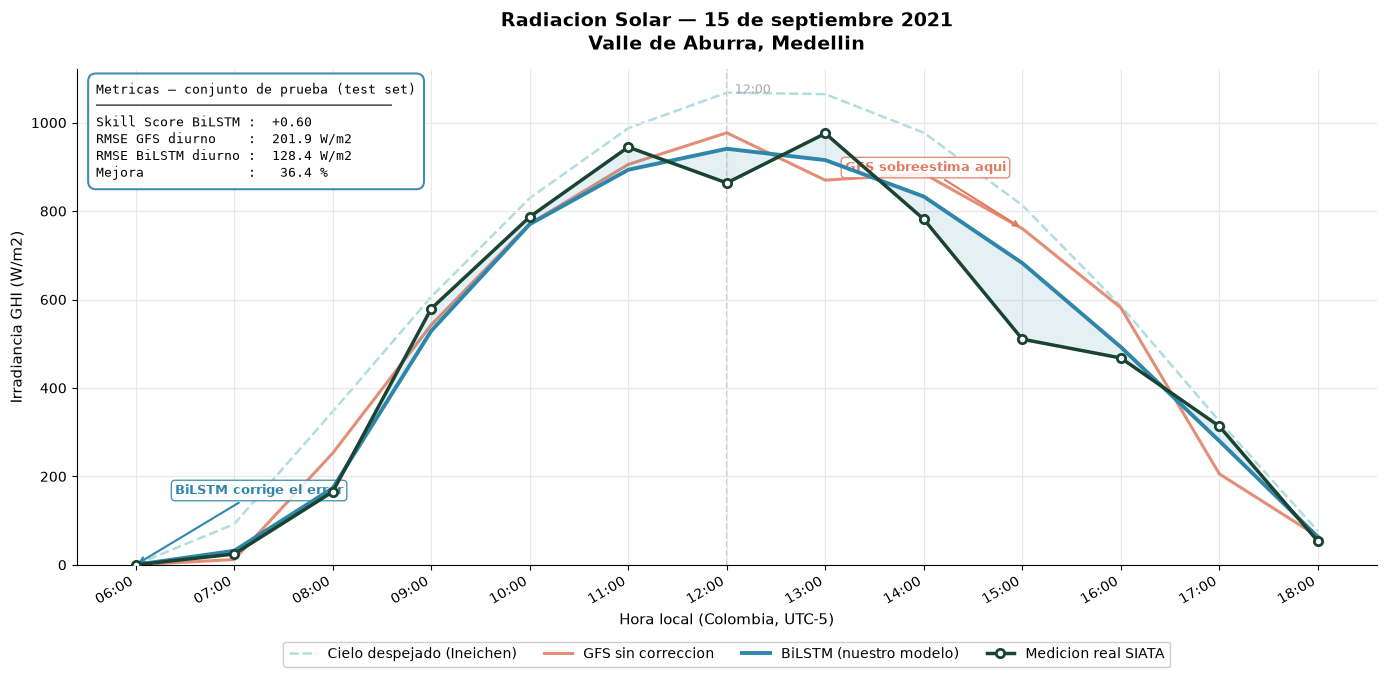

In [6]:
# ── Main visualisation: 4-line comparison figure ──────────────────
fig, ax = plt.subplots(figsize=(14, 7))

# Use integer positions on x-axis to avoid datetime rendering issues
x      = list(range(len(df_comp)))
labels = [ts.strftime('%H:%M') for ts in df_comp.index]

cs_vals     = df_comp['Clear_sky'].values
gfs_vals    = df_comp['GHI_GFS'].values
bilstm_vals = df_comp['GHI_BiLSTM'].values
siata_vals  = df_comp['GHI_SIATA'].values

# Line 1 — Clear-sky reference
ax.plot(x, cs_vals,
        color=COLOR_CS, linewidth=1.8, linestyle='--', alpha=0.9,
        label='Cielo despejado (Ineichen)', zorder=1)

# Line 2 — GFS raw
ax.plot(x, gfs_vals,
        color=COLOR_GFS, linewidth=2.2, alpha=0.85,
        label='GFS sin correccion', zorder=2)

# Line 3 — BiLSTM prediction
ax.plot(x, bilstm_vals,
        color=COLOR_BILSTM, linewidth=2.8,
        label='BiLSTM (nuestro modelo)', zorder=4)

# Line 4 — SIATA real measurement
ax.plot(x, siata_vals,
        color=COLOR_SIATA, linewidth=2.5,
        marker='o', markersize=6, markerfacecolor='white', markeredgewidth=2,
        label='Medicion real SIATA', zorder=5)

# Shaded area: error between BiLSTM and SIATA
ax.fill_between(x, bilstm_vals, siata_vals,
                alpha=0.12, color=COLOR_BILSTM,
                label='_nolegend_', zorder=3)

# Vertical line at noon
_noon_positions = [i for i, ts in enumerate(df_comp.index) if ts.hour == 12]
if _noon_positions:
    ax.axvline(_noon_positions[0], color='#AAAAAA', linestyle='--',
               linewidth=1.2, alpha=0.7, zorder=0)
    ax.text(_noon_positions[0] + 0.08,
            ax.get_ylim()[1] * 0.97 if ax.get_ylim()[1] > 0 else 950,
            '12:00', color='#AAAAAA', fontsize=9, va='top')

# ── Annotations ──────────────────────────────────────────────────
# Find the hour where GFS error is largest (absolute)
_gfs_err    = np.where(~np.isnan(gfs_vals), np.abs(gfs_vals - siata_vals), 0)
_bilstm_err = np.where(~np.isnan(bilstm_vals), np.abs(bilstm_vals - siata_vals), np.inf)
_pos_worst  = int(np.argmax(_gfs_err))
_pos_best   = int(np.argmin(_bilstm_err))

_y_worst = float(gfs_vals[_pos_worst]) if not np.isnan(gfs_vals[_pos_worst]) else 0
_y_best  = float(bilstm_vals[_pos_best]) if not np.isnan(bilstm_vals[_pos_best]) else 0

ax.annotate(
    'GFS sobreestima aqui',
    xy=(_pos_worst, _y_worst),
    xytext=(_pos_worst - 1.8, _y_worst + 130),
    fontsize=9, color=COLOR_GFS, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=COLOR_GFS, lw=1.5),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
              edgecolor=COLOR_GFS, alpha=0.85),
)
ax.annotate(
    'BiLSTM corrige el error',
    xy=(_pos_best, _y_best),
    xytext=(_pos_best + 0.4, _y_best + 160),
    fontsize=9, color=COLOR_BILSTM, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=COLOR_BILSTM, lw=1.5),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
              edgecolor=COLOR_BILSTM, alpha=0.85),
)

# ── Metrics text box (global test-set results) ────────────────────
_metrics_text = (
    'Metricas — conjunto de prueba (test set)\n'
    '─────────────────────────────────────\n'
    'Skill Score BiLSTM :  +0.60\n'
    'RMSE GFS diurno    :  201.9 W/m2\n'
    'RMSE BiLSTM diurno :  128.4 W/m2\n'
    'Mejora             :   36.4 %'
)
ax.text(
    0.015, 0.975, _metrics_text,
    transform=ax.transAxes, va='top', ha='left',
    fontsize=9.5, fontfamily='monospace',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='white',
              edgecolor=COLOR_BILSTM, alpha=0.92, linewidth=1.5),
)

# ── Labels and formatting ─────────────────────────────────────────
ax.set_title(
    'Radiacion Solar — 15 de septiembre 2021\nValle de Aburra, Medellin',
    fontsize=14, fontweight='bold', pad=14,
)
ax.set_xlabel('Hora local (Colombia, UTC-5)', fontsize=11)
ax.set_ylabel('Irradiancia GHI (W/m2)', fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}'))

ax.legend(
    loc='lower center', ncol=4,
    bbox_to_anchor=(0.5, -0.22),
    frameon=True, framealpha=0.95,
    edgecolor='#CCCCCC',
)

fig.tight_layout()

# ── Save figure ───────────────────────────────────────────────────
_fig_path = os.path.join(
    os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir()
    else os.getcwd(),
    'demo_climate_week_sep2021.png',
)
try:
    fig.savefig(_fig_path, dpi=150, bbox_inches='tight')
    print(f'Figura guardada -> {_fig_path}')
except Exception as _e:
    print(f'No se pudo guardar la figura: {_e}')

plt.show()

## Paso 4: ¿Qué tan bien predice el modelo?
### Análisis de error hora por hora

La curva anterior mostró **un solo día** (15 sep 2021).  
Ahora evaluamos el modelo sobre **todos los datos de prueba** — el 15 % del dataset que nunca vio durante el entrenamiento.

Cargamos las predicciones y valores reales desde `pred_real.csv` y exploramos tres vistas complementarias:

| Vista | Qué muestra |
|---|---|
| **Diagrama de dispersión** | Nube de puntos predicho vs. real — una predicción perfecta sería la diagonal |
| **SkillScore por hora** | Desglose hora a hora — revela dónde el modelo ayuda más y dónde está el mayor reto |
| **Producto final** | Lo que recibe Emergente cada mañana antes de las 8:00 AM |

Las métricas se calculan únicamente en horas **diurnas** (GHI real > 0 W/m²).

pred_real.csv: 5332 filas  |  columnas: ['y_true', 'y_pred']

Primeros 5 timestamps de pred_real.csv:
  2021-09-09 17:00:00  (tz=None)
  2022-01-29 06:00:00  (tz=None)
  2021-08-03 21:00:00  (tz=None)
  2024-04-20 16:00:00  (tz=None)
  2025-05-04 18:00:00  (tz=None)

y_true → 'y_true'  |  y_pred → 'y_pred'

Mediana y_true (todas las filas)    : 0.6667  ← baja por ceros nocturnos
Mediana y_true (solo valores > 0)   : 309.6
→ Escala detectada: W/m²  (NO multiplicar por clear-sky)

NaN después del reindex (tolerance 31 min):
  cs_pr      :     0 / 5332
  gfs_csi_pr :     0 / 5332
  y_true_pr  :     0 / 5332
  y_pred_pr  :     0 / 5332

Puntos diurnos válidos: 2857
GFS    → RMSE: 203.3 W/m²   R²: 0.589
BiLSTM → RMSE: 129.8 W/m²   R²: 0.832


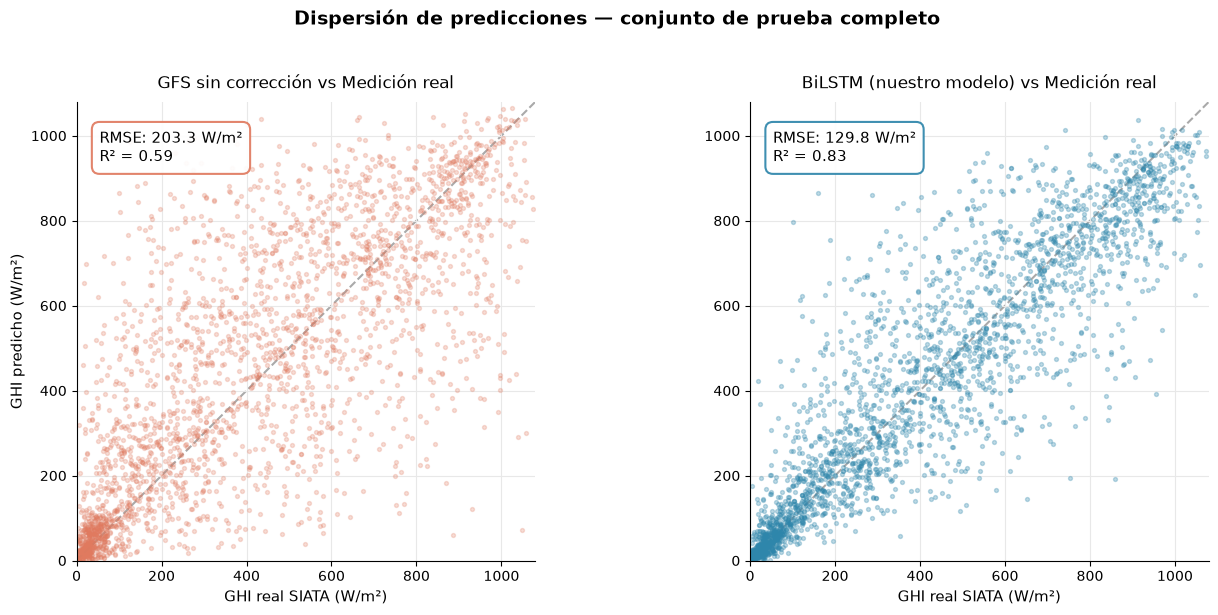

In [7]:
# ── Cell 12: Scatter plot — conjunto de prueba completo ──────────

# ── Load pred_real.csv ────────────────────────────────────────────
PRED_REAL_PATH = os.path.join(
    PROJECT_ROOT,
    '_4_LSTM_modules', '_runs', '4launch_multfeat_sym',
    '4launch_Multfeat_sym18_clim79_FIXED_BiLSTM_attn_20260706_102943',
    'pred_real.csv',
)
df_pr = pd.read_csv(PRED_REAL_PATH, index_col=0, parse_dates=True)
print(f'pred_real.csv: {len(df_pr)} filas  |  columnas: {list(df_pr.columns)}')

# ── Diagnose timestamps ───────────────────────────────────────────
print('\nPrimeros 5 timestamps de pred_real.csv:')
for ts in df_pr.index[:5]:
    print(f'  {ts}  (tz={getattr(ts, "tzinfo", None)})')

# ── Detect column names flexibly ──────────────────────────────────
def _find_col_pr(keywords):
    for kw in keywords:
        hits = [c for c in df_pr.columns if kw.lower() in c.lower()]
        if hits:
            return hits[0]
    raise KeyError(f'No column matching {keywords} in {list(df_pr.columns)}')

ytrue_col = _find_col_pr(['y_true', 'true', 'real', 'siata', 'obs'])
ypred_col = _find_col_pr(['y_pred', 'pred', 'bilstm', 'forecast'])
print(f'\ny_true → {ytrue_col!r}  |  y_pred → {ypred_col!r}')

t_pr      = df_pr.index
y_true_pr = df_pr[ytrue_col].values
y_pred_pr = df_pr[ypred_col].values

# ── Diagnose scale of y_true (W/m² or CSI?) ──────────────────────
_ytrue_pos       = y_true_pr[y_true_pr > 0.01]
_med_ytrue_day   = np.nanmedian(_ytrue_pos) if len(_ytrue_pos) > 0 else 0
_med_ytrue_all   = np.nanmedian(y_true_pr)
print(f'\nMediana y_true (todas las filas)    : {_med_ytrue_all:.4f}  '
      f'← baja por ceros nocturnos')
print(f'Mediana y_true (solo valores > 0)   : {_med_ytrue_day:.1f}')
_already_wm2 = _med_ytrue_day > 10
print(f'→ Escala detectada: {"W/m²  (NO multiplicar por clear-sky)" if _already_wm2 else "CSI  (multiplicar por clear-sky)"}')

# ── Load clear-sky GHI — nearest-match to pred_real timestamps ───
_ds_cs_pr  = xr.open_dataset(CS_GHI_PATH, engine='h5netcdf')
_cs_ser    = pd.Series(
    _ds_cs_pr['clear_sky_ghi'].values.squeeze(),
    index=pd.to_datetime(_ds_cs_pr['observation_time'].values),
)
_ds_cs_pr.close()

# Strip timezone from both sides before reindex
_cs_idx = _cs_ser.index
if _cs_idx.tz is not None:
    _cs_ser.index = _cs_idx.tz_localize(None)

t_pr_naive = pd.to_datetime(t_pr)
if t_pr_naive.tz is not None:
    t_pr_naive = t_pr_naive.tz_localize(None)

cs_pr = _cs_ser.reindex(
    t_pr_naive, method='nearest', tolerance=pd.Timedelta('31min')
).values

# ── Load GFS CSI — same nearest-match approach ────────────────────
_ds_gfs_pr  = xr.open_dataset(GFS_CSI_PATH, engine='h5netcdf')
_gfs_var_pr = list(_ds_gfs_pr.data_vars)[0]
_gfs_ser    = pd.Series(
    _ds_gfs_pr[_gfs_var_pr].values.squeeze(),
    index=pd.to_datetime(_ds_gfs_pr['observation_time'].values),
)
_ds_gfs_pr.close()

_gfs_idx = _gfs_ser.index
if _gfs_idx.tz is not None:
    _gfs_ser.index = _gfs_idx.tz_localize(None)

gfs_csi_pr = _gfs_ser.reindex(
    t_pr_naive, method='nearest', tolerance=pd.Timedelta('31min')
).values

# ── Diagnose NaN counts after reindex ────────────────────────────
print(f'\nNaN después del reindex (tolerance 31 min):')
print(f'  cs_pr      : {np.isnan(cs_pr).sum():5d} / {len(cs_pr)}')
print(f'  gfs_csi_pr : {np.isnan(gfs_csi_pr).sum():5d} / {len(gfs_csi_pr)}')
print(f'  y_true_pr  : {np.isnan(y_true_pr).sum():5d} / {len(y_true_pr)}')
print(f'  y_pred_pr  : {np.isnan(y_pred_pr).sum():5d} / {len(y_pred_pr)}')

# ── Assign GHI arrays (respecting detected scale) ────────────────
ghi_true_pr = y_true_pr            if _already_wm2 else y_true_pr * cs_pr
ghi_pred_pr = y_pred_pr            if _already_wm2 else y_pred_pr * cs_pr
ghi_gfs_pr  = gfs_csi_pr * cs_pr   # always CSI × clear-sky

# ── Daytime filter ────────────────────────────────────────────────
_mask_d = (
    (y_true_pr > 0) &
    ~np.isnan(y_true_pr) &
    ~np.isnan(y_pred_pr) &
    ~np.isnan(cs_pr) &
    ~np.isnan(gfs_csi_pr) &
    (cs_pr > 0)
)
_gt = ghi_true_pr[_mask_d]
_gp = ghi_pred_pr[_mask_d]
_gg = ghi_gfs_pr[_mask_d]
print(f'\nPuntos diurnos válidos: {_mask_d.sum()}')

# ── Compute real metrics ──────────────────────────────────────────
def _rmse(a, b):  return np.sqrt(np.nanmean((a - b) ** 2))
def _r2(a, b):
    ss_res = np.nansum((a - b) ** 2)
    ss_tot = np.nansum((a - np.nanmean(a)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

rmse_gfs    = _rmse(_gt, _gg)
r2_gfs      = _r2(_gt, _gg)
rmse_bilstm = _rmse(_gt, _gp)
r2_bilstm   = _r2(_gt, _gp)
print(f'GFS    → RMSE: {rmse_gfs:.1f} W/m²   R²: {r2_gfs:.3f}')
print(f'BiLSTM → RMSE: {rmse_bilstm:.1f} W/m²   R²: {r2_bilstm:.3f}')

# ── Scatter figure ────────────────────────────────────────────────
_lim = min(
    np.nanpercentile(np.concatenate([_gt, _gg, _gp]), 99.5) * 1.05,
    1250,
)

fig_sc, axes_sc = plt.subplots(1, 2, figsize=(14, 6))

for _ax in axes_sc:
    _ax.plot([0, _lim], [0, _lim],
             color='#AAAAAA', lw=1.5, ls='--', zorder=1)
    _ax.set_xlim(0, _lim)
    _ax.set_ylim(0, _lim)
    _ax.set_xlabel('GHI real SIATA (W/m²)', fontsize=11)
    _ax.set_aspect('equal', adjustable='box')

# LEFT — GFS vs SIATA
axes_sc[0].scatter(_gt, _gg, color=COLOR_GFS, alpha=0.25, s=8, zorder=2)
axes_sc[0].set_ylabel('GHI predicho (W/m²)', fontsize=11)
axes_sc[0].set_title('GFS sin corrección vs Medición real', fontsize=12, pad=10)
axes_sc[0].text(
    0.05, 0.94,
    f'RMSE: {rmse_gfs:.1f} W/m²\nR² = {r2_gfs:.2f}',
    transform=axes_sc[0].transAxes, fontsize=11, va='top',
    bbox=dict(boxstyle='round,pad=0.5', fc='white', ec=COLOR_GFS, alpha=0.92, lw=1.5),
)

# RIGHT — BiLSTM vs SIATA
axes_sc[1].scatter(_gt, _gp, color=COLOR_BILSTM, alpha=0.3, s=8, zorder=2)
axes_sc[1].set_title('BiLSTM (nuestro modelo) vs Medición real', fontsize=12, pad=10)
axes_sc[1].text(
    0.05, 0.94,
    f'RMSE: {rmse_bilstm:.1f} W/m²\nR² = {r2_bilstm:.2f}',
    transform=axes_sc[1].transAxes, fontsize=11, va='top',
    bbox=dict(boxstyle='round,pad=0.5', fc='white', ec=COLOR_BILSTM, alpha=0.92, lw=1.5),
)

fig_sc.suptitle(
    'Dispersión de predicciones — conjunto de prueba completo',
    fontsize=14, fontweight='bold', y=1.02,
)
fig_sc.tight_layout()
plt.show()

## Paso 5: ¿En qué horas mejora más el modelo?
### SkillScore por hora del día

El **SkillScore** compara el error del modelo contra el error del GFS sin corrección:

$$\text{SkillScore} = 1 - \frac{\text{MSE}_{\text{BiLSTM}}}{\text{MSE}_{\text{GFS}}}$$

| Valor | Interpretación |
|-------|----------------|
| **0** | El modelo iguala al GFS (sin mejora) |
| **0.6** | El modelo reduce el error en un 40 % respecto al GFS |
| **1** | Predicción perfecta (error = 0) |

Calculamos el SkillScore **para cada hora por separado** para identificar:
- Las horas donde el modelo aporta más valor
- Las horas más difíciles (niebla matutina, convección vespertina)

SkillScore por hora:
  06:00  SS = 0.634
  07:00  SS = 0.602
  08:00  SS = 0.666
  09:00  SS = 0.689
  10:00  SS = 0.675
  11:00  SS = 0.588
  12:00  SS = 0.569
  13:00  SS = 0.578
  14:00  SS = 0.515
  15:00  SS = 0.607
  16:00  SS = 0.575
  17:00  SS = 0.684
  18:00  SS = 0.483


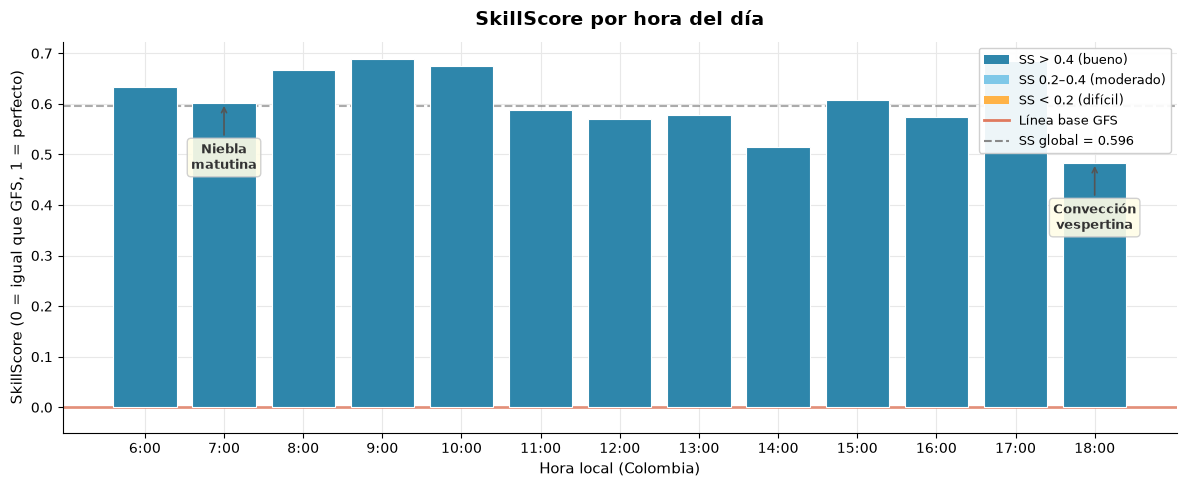

In [8]:
# ── Cell 14: SkillScore por hora del día ─────────────────────────
#   Uses ghi_true_pr, ghi_pred_pr, ghi_gfs_pr, t_pr from Cell 12

hours_pr = pd.to_datetime(t_pr).hour

skill_per_hour = {}
for _h in range(6, 19):
    _mh = (
        (hours_pr == _h) &
        (ghi_true_pr > 0) &
        ~np.isnan(ghi_true_pr) &
        ~np.isnan(ghi_gfs_pr) &
        ~np.isnan(ghi_pred_pr)
    )
    if _mh.sum() < 5:
        continue
    _gt_h = ghi_true_pr[_mh]
    _gp_h = ghi_pred_pr[_mh]
    _gg_h = ghi_gfs_pr[_mh]
    _mse_gfs    = np.mean((_gg_h - _gt_h) ** 2)
    _mse_bilstm = np.mean((_gp_h - _gt_h) ** 2)
    skill_per_hour[_h] = (1 - _mse_bilstm / _mse_gfs) if _mse_gfs > 0 else np.nan

hours_plot = sorted(skill_per_hour.keys())
ss_values  = [skill_per_hour[h] for h in hours_plot]

print('SkillScore por hora:')
for _h, _ss in zip(hours_plot, ss_values):
    print(f'  {_h:02d}:00  SS = {_ss:.3f}')

# ── Bar colours ───────────────────────────────────────────────────
bar_colors_ss = []
for _ss in ss_values:
    if np.isnan(_ss):
        bar_colors_ss.append('#CCCCCC')
    elif _ss > 0.4:
        bar_colors_ss.append(COLOR_BILSTM)   # blue — good
    elif _ss > 0.2:
        bar_colors_ss.append('#7FC8E8')        # light blue — moderate
    else:
        bar_colors_ss.append('#FFB347')        # light orange — difficult

# ── Bar chart ─────────────────────────────────────────────────────
fig_ss, ax_ss = plt.subplots(figsize=(12, 5))
ax_ss.bar(hours_plot, ss_values, color=bar_colors_ss,
          edgecolor='white', linewidth=0.8, zorder=3)

# Reference lines
ax_ss.axhline(0,     color=COLOR_GFS, lw=2,   ls='-',  alpha=0.8,
              label='Línea base GFS (SS = 0)', zorder=2)
ax_ss.axhline(0.596, color='#888888', lw=1.5, ls='--', alpha=0.7,
              label='SkillScore global = 0.596', zorder=2)

# Annotate worst morning and afternoon hours
_morning_hrs   = [h for h in hours_plot if h <= 9]
_afternoon_hrs = [h for h in hours_plot if h >= 14]
worst_am = min(_morning_hrs,   key=lambda h: skill_per_hour.get(h, 1)) if _morning_hrs else None
worst_pm = min(_afternoon_hrs, key=lambda h: skill_per_hour.get(h, 1)) if _afternoon_hrs else None

for _h_ann, _lbl_ann in [(worst_am, 'Niebla\nmatutina'), (worst_pm, 'Convección\nvespertina')]:
    if _h_ann is None:
        continue
    _ss_ann = skill_per_hour.get(_h_ann, 0)
    _y_text = _ss_ann - 0.13 if _ss_ann > 0 else _ss_ann - 0.08
    ax_ss.annotate(
        _lbl_ann,
        xy=(_h_ann, _ss_ann),
        xytext=(_h_ann, _y_text),
        ha='center', fontsize=9, color='#333333', fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='#555555', lw=1.2),
        bbox=dict(boxstyle='round,pad=0.3', fc='#FFFDE7', ec='#CCCCCC', alpha=0.9),
    )

ax_ss.set_title('SkillScore por hora del día', fontsize=14, fontweight='bold', pad=12)
ax_ss.set_xlabel('Hora local (Colombia)', fontsize=11)
ax_ss.set_ylabel('SkillScore (0 = igual que GFS, 1 = perfecto)', fontsize=11)
ax_ss.set_xticks(hours_plot)
ax_ss.set_xticklabels([f'{h}:00' for h in hours_plot])

_ss_min_val = min(v for v in ss_values if not np.isnan(v))
ax_ss.set_ylim(bottom=min(_ss_min_val - 0.12, -0.05))

ax_ss.legend(
    handles=[
        mpatches.Patch(facecolor=COLOR_BILSTM, label='SS > 0.4 (bueno)'),
        mpatches.Patch(facecolor='#7FC8E8',    label='SS 0.2–0.4 (moderado)'),
        mpatches.Patch(facecolor='#FFB347',    label='SS < 0.2 (difícil)'),
        plt.Line2D([0], [0], color=COLOR_GFS,  lw=2,   label='Línea base GFS'),
        plt.Line2D([0], [0], color='#888888', lw=1.5, ls='--', label='SS global = 0.596'),
    ],
    loc='upper right', fontsize=9, framealpha=0.92,
)

fig_ss.tight_layout()
plt.show()

## Paso 6: El producto final para el mercado energético
### ¿Qué recibe Emergente cada mañana?

**Flujo operativo diario:**

```
4:00 AM  →  Modelo corre automáticamente con GFS del lanzamiento 00 UTC
4:05 AM  →  Se genera la curva de pronóstico horario para el día
4:10 AM  →  El equipo de Emergente recibe el pronóstico
8:00 AM  →  Deadline para declarar oferta energética a XM (mercado mayorista)
```

**¿Por qué importa la precisión?**

- Una mejor predicción → menor riesgo de desbalance energético
- Menos riesgo → menor cargo por desvío en el mercado
- Resultado: **mayor rentabilidad** para la planta solar

**Próximo paso:** Incorporar imágenes del satélite **GOES-19** para capturar la nubosidad local en tiempo real antes de las 8:00 AM.

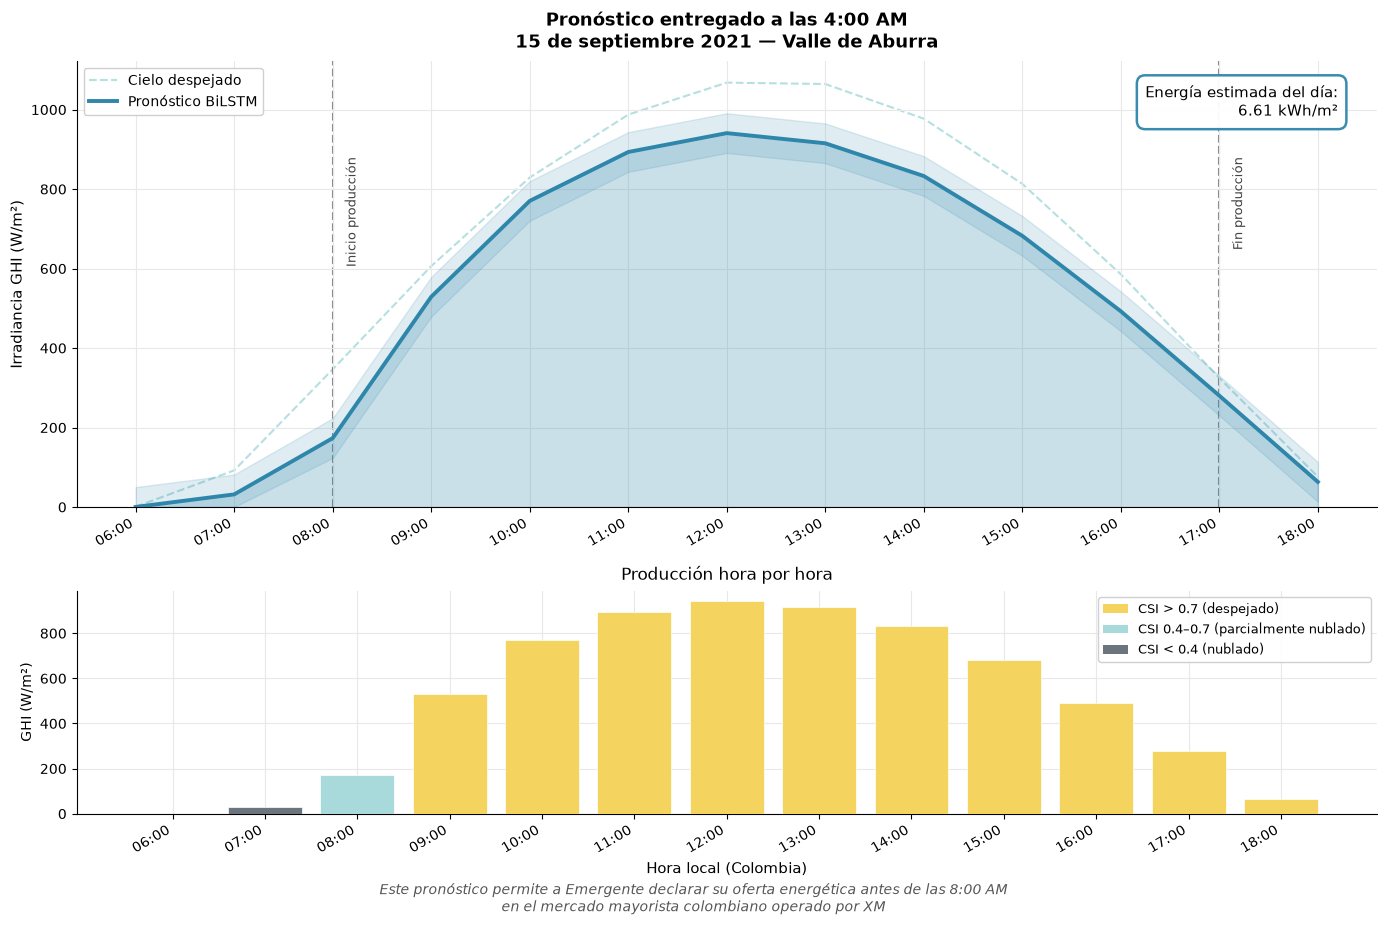

In [9]:
# ── Cell 16: Producto final — pronóstico entregado a las 4:00 AM ─
#   Uses Sep 15 2021 data from df_comp (Cell 9) and df_pred (Cell 6)

# ── Align CSI predictions with df_comp timestamps ────────────────
_sr_csi_day = pd.Series(df_pred['csi_pred'].values, index=df_pred.index)
_csi_day    = _sr_csi_day.reindex(df_comp.index).fillna(0).values

_x          = list(range(len(df_comp)))
_xlabels    = [ts.strftime('%H:%M') for ts in df_comp.index]
_bilstm_day = df_comp['GHI_BiLSTM'].fillna(0).values
_cs_day     = df_comp['Clear_sky'].fillna(0).values

# ── Daily energy estimate (hourly data → Wh/m² → kWh/m²) ────────
_energy_kwh = _bilstm_day.sum() / 1000

# ── Figure ────────────────────────────────────────────────────────
fig_prod, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(14, 9), gridspec_kw={'height_ratios': [2, 1]}
)

# ── TOP panel: GHI forecast curve ────────────────────────────────
ax_top.plot(_x, _cs_day, color=COLOR_CS, lw=1.5, ls='--', alpha=0.85,
            label='Cielo despejado', zorder=1)

# Uncertainty band ±50 W/m²
ax_top.fill_between(_x,
                    np.maximum(_bilstm_day - 50, 0),
                    _bilstm_day + 50,
                    alpha=0.15, color=COLOR_BILSTM, zorder=2)

# Fill under BiLSTM curve
ax_top.fill_between(_x, 0, _bilstm_day, alpha=0.25, color=COLOR_BILSTM, zorder=2)

# BiLSTM line
ax_top.plot(_x, _bilstm_day, color=COLOR_BILSTM, lw=2.8,
            label='Pronóstico BiLSTM', zorder=3)

# Vertical reference lines at 8am and 5pm
for _h_prod, _lbl_prod in [(8, 'Inicio producción'), (17, 'Fin producción')]:
    _idx_h = [i for i, ts in enumerate(df_comp.index) if ts.hour == _h_prod]
    if _idx_h:
        ax_top.axvline(_idx_h[0], color='#555555', ls='--', lw=1.5, alpha=0.7, zorder=1)
        ax_top.text(_idx_h[0] + 0.12, 880, _lbl_prod,
                    fontsize=9, color='#444444', rotation=90, va='top')

# Energy annotation box
ax_top.text(
    0.97, 0.95,
    f'Energía estimada del día:\n{_energy_kwh:.2f} kWh/m²',
    transform=ax_top.transAxes, ha='right', va='top', fontsize=11,
    bbox=dict(boxstyle='round,pad=0.55', fc='white', ec=COLOR_BILSTM,
              alpha=0.95, lw=1.8),
)

ax_top.set_title(
    'Pronóstico entregado a las 4:00 AM\n15 de septiembre 2021 — Valle de Aburra',
    fontsize=13, fontweight='bold', pad=10,
)
ax_top.set_ylabel('Irradiancia GHI (W/m²)', fontsize=11)
ax_top.set_xticks(_x)
ax_top.set_xticklabels(_xlabels, rotation=30, ha='right')
ax_top.set_ylim(bottom=0)
ax_top.legend(loc='upper left', fontsize=10, framealpha=0.92)

# ── BOTTOM panel: hourly bar chart colored by CSI ─────────────────
_bar_colors_prod = []
for _csi_val in _csi_day:
    if _csi_val > 0.7:
        _bar_colors_prod.append('#F4D35E')   # sunny yellow
    elif _csi_val > 0.4:
        _bar_colors_prod.append('#A8DADC')   # partly cloudy blue
    else:
        _bar_colors_prod.append('#6C757D')   # cloudy gray

ax_bot.bar(_x, _bilstm_day, color=_bar_colors_prod, edgecolor='white', lw=0.5, zorder=3)

ax_bot.legend(
    handles=[
        mpatches.Patch(fc='#F4D35E', label='CSI > 0.7 (despejado)'),
        mpatches.Patch(fc='#A8DADC', label='CSI 0.4–0.7 (parcialmente nublado)'),
        mpatches.Patch(fc='#6C757D', label='CSI < 0.4 (nublado)'),
    ],
    loc='upper right', fontsize=9, framealpha=0.92,
)
ax_bot.set_title('Producción hora por hora', fontsize=12, pad=8)
ax_bot.set_ylabel('GHI (W/m²)', fontsize=10)
ax_bot.set_xlabel('Hora local (Colombia)', fontsize=11)
ax_bot.set_xticks(_x)
ax_bot.set_xticklabels(_xlabels, rotation=30, ha='right')
ax_bot.set_ylim(bottom=0)

# ── Bottom footnote ───────────────────────────────────────────────
fig_prod.text(
    0.5, -0.02,
    'Este pronóstico permite a Emergente declarar su oferta energética antes de las 8:00 AM\n'
    'en el mercado mayorista colombiano operado por XM',
    ha='center', fontsize=10, style='italic', color='#555555',
)

fig_prod.tight_layout()
plt.show()

## Conclusión

### Sistema de tres capas para predicción solar

```
GFS (física global)  →  BiLSTM (corrección local)  →  GOES-19 (próximo)
Resolución: 0.25°       Resolución: puntual              Resolución: 2 km
Actualización: 6 h      Latencia: < 1 min               Actualización: 10 min
```

### Resultados del modelo actual

| Métrica | GFS | BiLSTM | Mejora |
|---------|-----|--------|--------|
| SkillScore | 0.000 | +0.596 | — |
| RMSE diurno | 201.9 W/m² | 128.4 W/m² | **−36.4 %** |
| R² | 0.65 | 0.90 | **+0.25** |
| Mejora relativa | — | — | **36.4 %** |

### Próximos pasos

1. **GOES-19**: integración de imágenes satelitales del disco completo (resolución 2 km)
2. **ConvLSTM**: arquitectura que aprende patrones espaciales de nubosidad
3. **Meta**: SkillScore > 0.70 con GOES-19 + BiLSTM ensemble

---

*Datos: Red SIATA — Sistema de Alerta Temprana del Valle de Aburra · GFS: NOAA Global Forecast System 0.25°*



---

```

---

**Repositorio del proyecto:** disponible en el servidor interno Emergente  
**Datos:** Red SIATA — Sistema de Alerta Temprana del Valle de Aburra  
**Modelo GFS:** NOAA Global Forecast System (GFS 0.25°)